In [1]:
!pip install ska-ost-low-uv@git+https://gitlab.com/ska-telescope/ost/ska-ost-low-uv

  Cloning https://gitlab.com/ska-telescope/ost/ska-ost-low-uv to /tmp/pip-install-clh_vcfa/ska-ost-low-uv_de20c8f60c9143cc89115fe8fd5347d9
  Running command git clone --filter=blob:none --quiet https://gitlab.com/ska-telescope/ost/ska-ost-low-uv /tmp/pip-install-clh_vcfa/ska-ost-low-uv_de20c8f60c9143cc89115fe8fd5347d9
  Resolved https://gitlab.com/ska-telescope/ost/ska-ost-low-uv to commit 4f238d8886adf8f7da47650659124b0749fdde40
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 49.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━

In [2]:
!pip install ska-ost-low-uv[postx]@git+https://gitlab.com/ska-telescope/ost/ska-ost-low-uv

  Cloning https://gitlab.com/ska-telescope/ost/ska-ost-low-uv to /tmp/pip-install-mx10xqc6/ska-ost-low-uv_1593497416f7458eba05fa448ad5ade0
  Running command git clone --filter=blob:none --quiet https://gitlab.com/ska-telescope/ost/ska-ost-low-uv /tmp/pip-install-mx10xqc6/ska-ost-low-uv_1593497416f7458eba05fa448ad5ade0
  Resolved https://gitlab.com/ska-telescope/ost/ska-ost-low-uv to commit 4f238d8886adf8f7da47650659124b0749fdde40
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 15.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 42.5 MB/s  0:00:026m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 41.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 665.2/665.2 kB 26.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from ska_ost_low_uv.postx import ApertureArray
from ska_ost_low_uv.io import hdf5_to_uvx
from ska_ost_low_uv.utils import get_test_data

from astropy.time import Time
from astropy.units import Quantity
from astropy.coordinates import SkyCoord

import pylab as plt
import numpy as np

In [2]:
from pyuvdata.analytic_beam import ShortDipoleBeam

In [116]:
# Set time to 2 PM in January, so sun is high but not at zenith (6AM UTC)
t = Time(['2026-02-01 07:00:00'], format='iso')
f = Quantity([200], unit='MHz')

aa = ApertureArray(station_id='s9-5', sim_f=f, sim_t=t)

# Create sun as a sky coordinate (pretend ICRS = GCRS)
sun_gcrs = aa.coords.get_sun()
sun = SkyCoord(sun_gcrs.ra, sun_gcrs.dec)

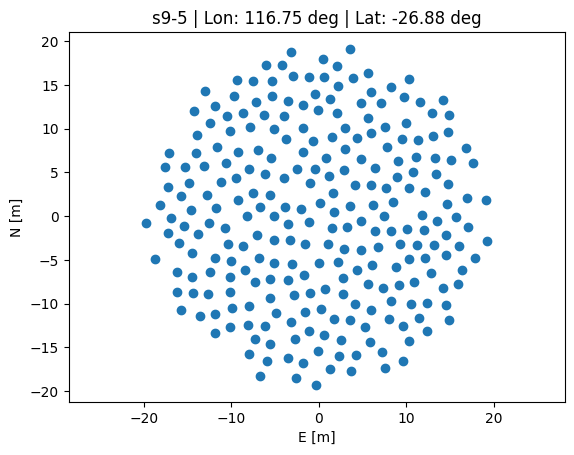

In [117]:
aa.plotting.plot_antennas()

In [118]:
# Generate simulated visibilities, and create image
vis = aa.simulation.sim_vis_gsm()
img = aa.imaging.make_image(vis=vis[0,0])

In [119]:
vis.shape

(1, 1, 256, 256, 4)

In [120]:
vis.dims

('time', 'frequency', 'ant1', 'ant2', 'polarization')

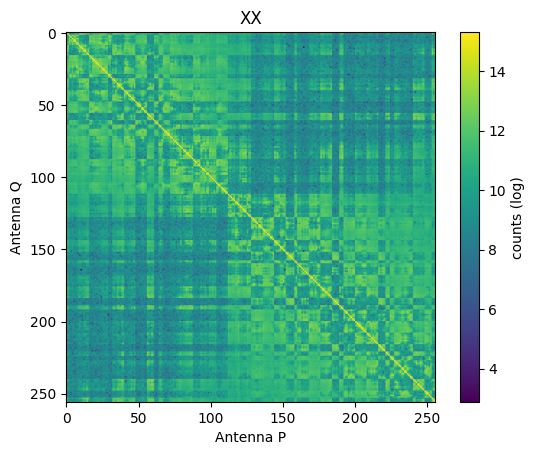

In [121]:
aa.plotting.plot_corr_matrix(vis='model')

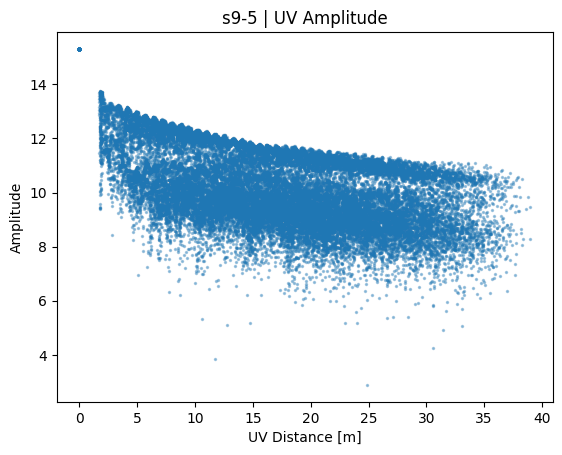

In [122]:
aa.plotting.plot_uvdist_amp(vis='model',sfunc=np.log)

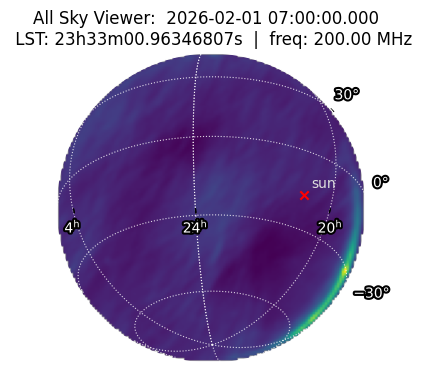

In [123]:
aa.viewer.skycat = {'sun': sun}
aa.viewer.orthview(img, pol_idx=0, overlay_srcs=True)

In [124]:
# Create a sky model with only the Sun and simulate visibilities

# Magnitude will be set to 1
sky_model = {'sun': sun}

# Generate model visibilities
# As the magnitude = 1, these are equivalent to the phase matrix above
# (but returned as an xarray with more dimensions)
sun_model_vis = aa.simulation.sim_vis_pointsrc(sky_model)
print(sun_model_vis.dims)
print(sun_model_vis.shape)

('time', 'frequency', 'ant1', 'ant2', 'polarization')
(1, 1, 256, 256, 4)


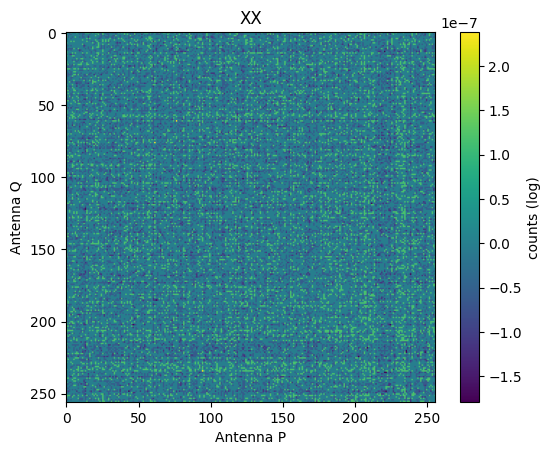

In [125]:
aa.plotting.plot_corr_matrix(vis='model')

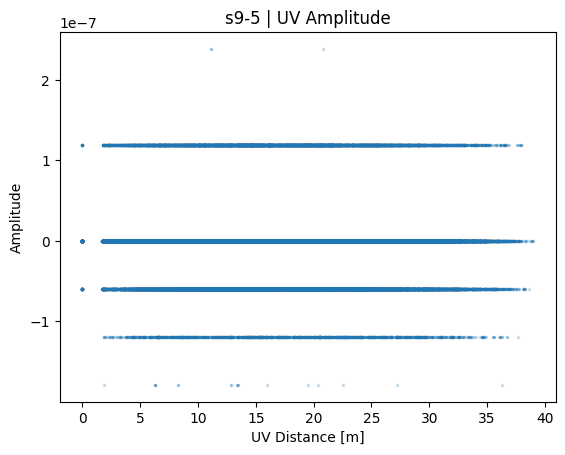

In [126]:
aa.plotting.plot_uvdist_amp(vis='model',sfunc=np.log)

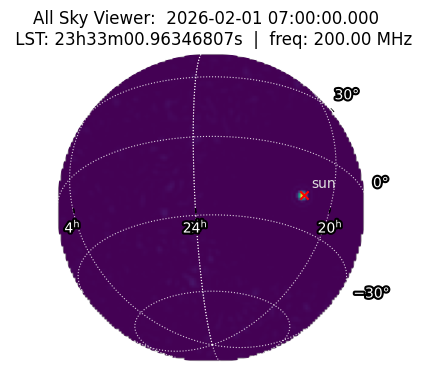

In [127]:
img = aa.imaging.make_image(vis=sun_model_vis[0,0])
aa.viewer.orthview(img, pol_idx=0, overlay_srcs=True)

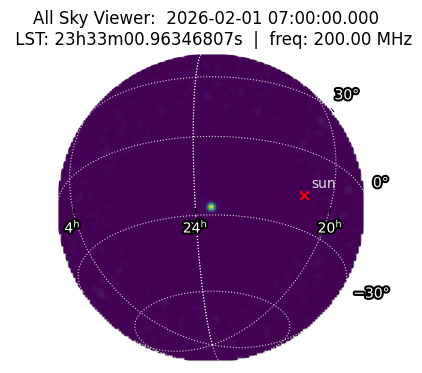

In [128]:
img = aa.imaging.make_image(vis=sun_model_vis[0,0]*np.conj(sun_model_vis[0,0]))
aa.viewer.orthview(img, pol_idx=0, overlay_srcs=True)

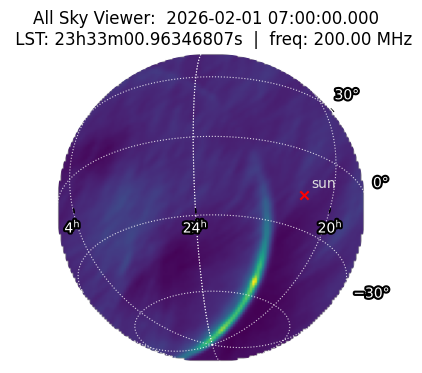

In [129]:

img = aa.imaging.make_image(vis=vis[0,0] * np.conj(sun_model_vis[0,0]))
aa.viewer.orthview(img, overlay_srcs=True)

In [ ]:
aa.

array([[ 0.       ,  3.7503586,  9.467381 , ...,  1.8578475,  2.2427745,
         2.1356876],
       [ 3.7503586,  0.       ,  5.970906 , ...,  4.600962 ,  5.9512005,
         5.522062 ],
       [ 9.467381 ,  5.970906 ,  0.       , ..., 10.565413 , 11.70824  ,
        10.72986  ],
       ...,
       [ 1.8578475,  4.600962 , 10.565413 , ...,  0.       ,  2.101277 ,
         3.4079158],
       [ 2.2427745,  5.9512005, 11.70824  , ...,  2.101277 ,  0.       ,
         2.0645125],
       [ 2.1356876,  5.522062 , 10.72986  , ...,  3.4079158,  2.0645125,
         0.       ]], shape=(256, 256), dtype=float32)